# Demand forecasting with random forest

This project analyzes the behavior of daily demand from a database extracted from Kaggle.


The following libraries will be used for development:

In [4]:
# data manipulation
import numpy as np
import pandas as pd

# data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# data forecasting
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Import data

The dataset used is "Retail Store Inventory and Demand Forecasting" from: https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting

In [7]:
df = pd.read_csv("sales_data.csv")

In [8]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [9]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


Change data types:

In [11]:
# Date
df['Date'] = pd.to_datetime(df['Date'])

# Categorical variables
cat_cols = ["Store ID", "Product ID", "Category", "Region", 
            "Weather Condition", "Seasonality"]
df[cat_cols] = df[cat_cols].astype("category")

# Integers
num_cols = ["Inventory Level", "Units Sold", "Units Ordered", "Discount", "Demand"]
df[num_cols] = df[num_cols].clip(lower=0)
df[num_cols] = df[num_cols].astype("Int64")


# flots
flots_cols = ["Price", "Competitor Pricing"]
df[flots_cols] = df[flots_cols].astype("float32")

# Booleans
bool_cols = ["Promotion", "Epidemic"]
df[bool_cols] = df[bool_cols].astype("bool")

# EDA

This section is for exploratory analysis. 

In [14]:
df.nunique()

Date                    760
Store ID                  5
Product ID               20
Category                  5
Region                    4
Inventory Level        1426
Units Sold              330
Units Ordered           996
Price                 15396
Discount                  6
Weather Condition         4
Promotion                 2
Competitor Pricing    15963
Seasonality               4
Epidemic                  2
Demand                  340
dtype: int64

From this summary, we can see that dataset contains a data sales from 5 stores, 20 products agruped into 5 categories.
The data sales are from 760 days, representing 2 years of daily sales

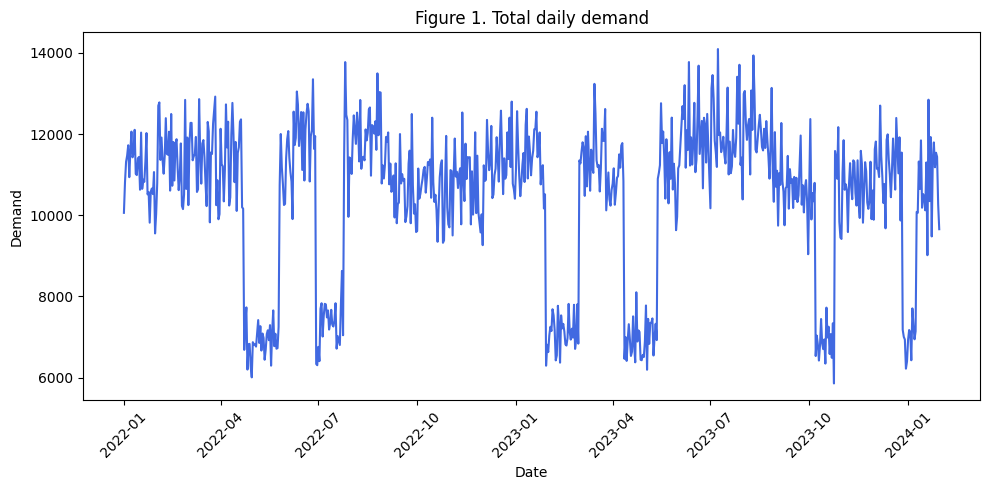

In [16]:
demanda_diaria = df.groupby("Date", as_index=False)["Demand"].sum()

plt.figure(figsize=(10, 5))
sns.lineplot(data=demanda_diaria, x="Date", y="Demand", color="royalblue")
plt.title("Figure 1. Total daily demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The figure shows daily demand trends from January 2022 through 2024.
Demands fluctuate between 10,000 and 12,000 units per day, with several noticeable drops across months and following a recurring seasonal pattern.

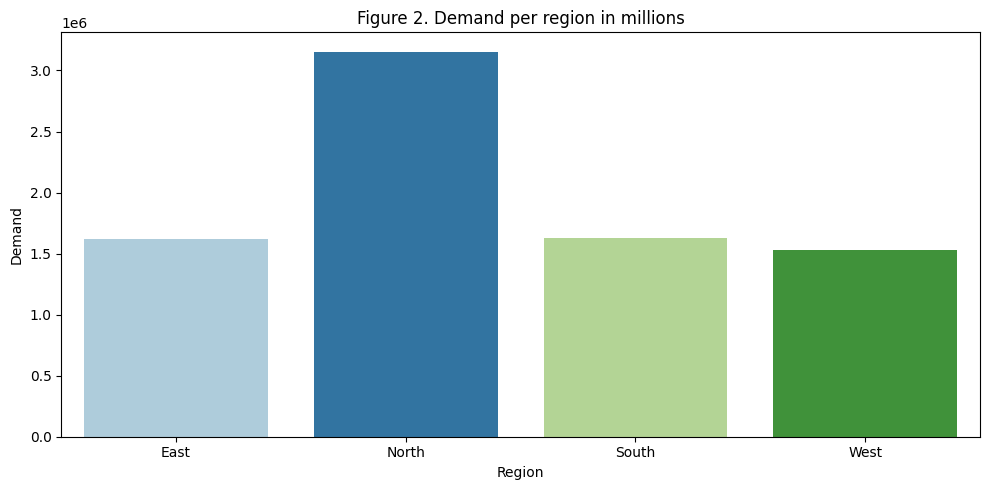

In [18]:
demanda_region = df.groupby("Region", as_index=False, observed=True)["Demand"].sum()
plt.figure(figsize=(10, 5))
sns.barplot(demanda_region, x="Region", y="Demand", hue="Region", palette= 'Paired')
plt.title("Figure 2. Demand per region in millions")
plt.xlabel("Region")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

North is a region with more demand, doubling the units of the others regions.

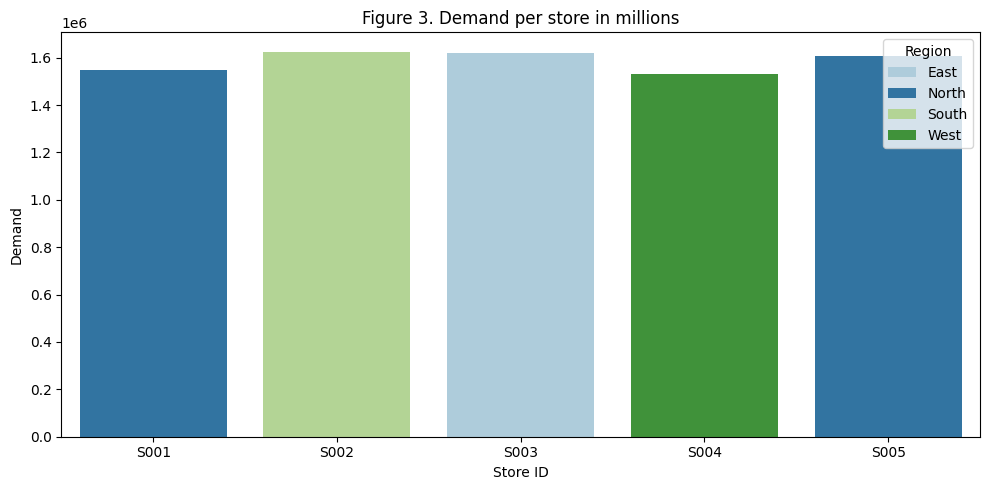

In [20]:
demanda_tienda = df.groupby(["Store ID", "Region"], as_index=False, observed= True)["Demand"].sum()
plt.figure(figsize=(10, 5))
sns.barplot(demanda_tienda, x="Store ID", y="Demand", hue= "Region" , palette= 'Paired')
plt.title("Figure 3. Demand per store in millions")
plt.xlabel("Store ID")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

The high demand in the nort region is because stores 01 and 05 are located in the same region

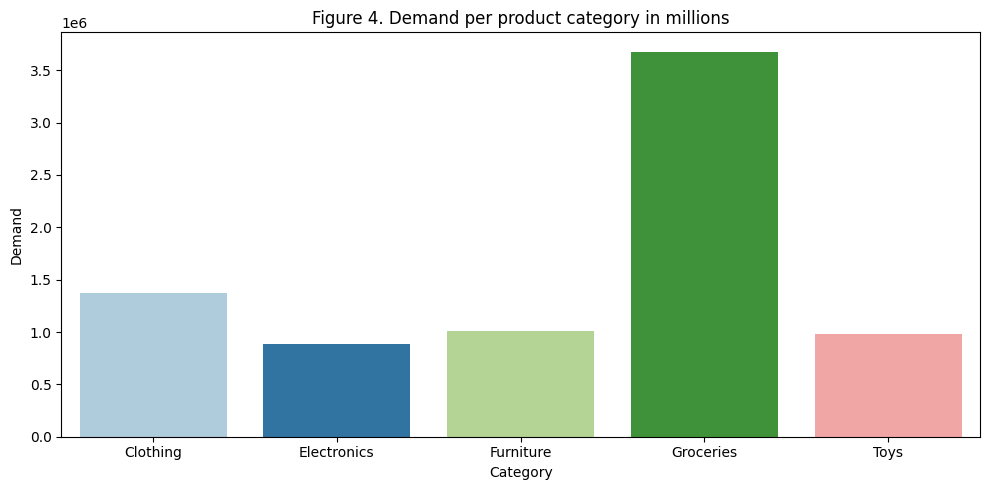

In [22]:
demanda_categorias = df.groupby("Category", as_index=False, observed= True)["Demand"].sum()
plt.figure(figsize=(10, 5))
sns.barplot(demanda_categorias, x="Category", y="Demand", hue= "Category", palette= 'Paired')
plt.title("Figure 4. Demand per product category in millions")
plt.xlabel("Category")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

The most polulars categorys is Groceries with 3.5 millions of demand

# Unit Root test
In the **Figure 1**, the daily demand have a recurring pattern, to determine whether demand is stationary and an ARIMA model should be applied, the unit root test is applied. 
- **H₀**: the series has a unit root (it is not stationary)
- **H₁**: the series is stationary


In [25]:
# sort the demand by time series
serie = df.copy()
serie = serie.sort_values('Date').set_index('Date')

# group to univariant series
y_ts = serie['Demand'].groupby('Date').sum()
y_ts.index.freq = 'D'

#Test
result = adfuller(y_ts) 
print(f"ADF Statistic: {result[0]:.4f}") 
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.8816
p-value: 0.0000


The statistical value of the test is very negative and the p-value is less than 0.05, so **the null hypothesis (H₀) is rejected, and the demand series is stationary.**

**An ARIMA model is appropriate for the forecasting** 

## ARIMA



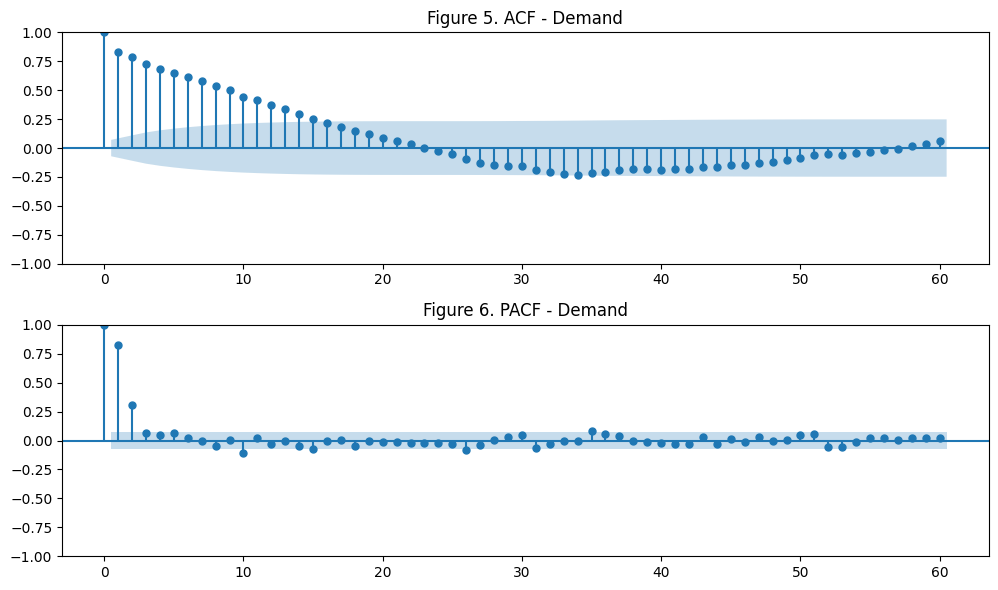

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(y_ts.dropna(), ax=ax[0], lags=60)
ax[0].set_title("Figure 5. ACF - Demand")
plot_pacf(y_ts.dropna(), ax=ax[1], lags=60, method='ywm')
ax[1].set_title("Figure 6. PACF - Demand")
plt.tight_layout()
plt.show()

The Autocorrelation Function (Figure 5) it can be seen that demand correlates with several lags. In Partial Autocorrelation (Figure 6), lag 1 indicates that the current value depends on the previous value.

In [30]:
# order= (p, d, q)
# p=1 PACF tiene un pico en el rezago 1
# d=0 Adfuller serie estacionaria = 0, no estacionaria = 1 diferencia o 2 diferencias
# q=2 ACF tiene un rezago y luego cae, q  >= 2

model_arima = ARIMA(y_ts, order=(1, 0, 2))
results = model_arima.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                 Demand   No. Observations:                  760
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6332.981
Date:                Thu, 20 Nov 2025   AIC                          12675.962
Time:                        11:35:17   BIC                          12699.128
Sample:                    01-01-2022   HQIC                         12684.883
                         - 01-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.043e+04    351.503     29.677      0.000    9742.783    1.11e+04
ar.L1          0.9331      0.018     52.329      0.000       0.898       0.968
ma.L1         -0.3848      0.032    -12.117      0.0

The model results show that the variables are significant, except for lag 2. The model could be simplified to (1, 0, 1).

The p-value of Jarque-Bera is is less than 0.05, the residuals do not have a normal distribution.


In [32]:
model_arima2 = ARIMA(y_ts, order=(1, 0, 1))
results_2 = model_arima2.fit()
print(results_2.summary())

                               SARIMAX Results                                
Dep. Variable:                 Demand   No. Observations:                  760
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6333.151
Date:                Thu, 20 Nov 2025   AIC                          12674.302
Time:                        11:35:18   BIC                          12692.835
Sample:                    01-01-2022   HQIC                         12681.439
                         - 01-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.043e+04    358.742     29.079      0.000    9728.594    1.11e+04
ar.L1          0.9367      0.016     56.961      0.000       0.904       0.969
ma.L1         -0.3831      0.031    -12.184      0.0

This second ARIMA model **has better coefficients (AIC, BIC, HQIC)**, **the parameters are significant, this model are simpler without losing its explanatory power**. 

The model have a **p-value of Jarque-Bera is is less than 0.05**, in this new model **the residuals no have a normal distribution.**

For the model to be valid, it must not have autocorrelation (p-value of Ljung-Box > 0.05).

The residuals must follow a normal distribution (p-value of Jarque-Bera > 0.05), this model does not appear to have a normal distribution of its residuals.

They must have heteroscedasticity or constant variance (p-value H > 0.05).


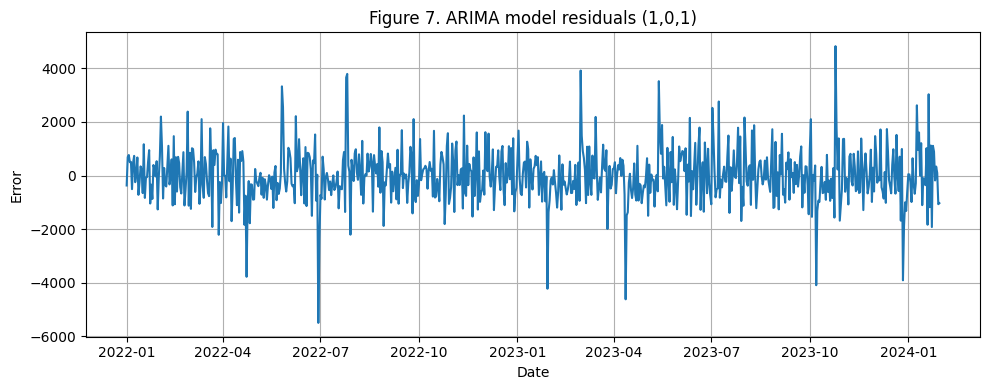

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(results_2.resid)
plt.title("Figure 7. ARIMA model residuals (1,0,1)")
plt.xlabel("Date")
plt.ylabel("Error")
plt.grid(True)
plt.tight_layout()
plt.show()

The residuals show outliers that are not captured by the model, variables that have not been considered, or exogenous factors that influence demand.

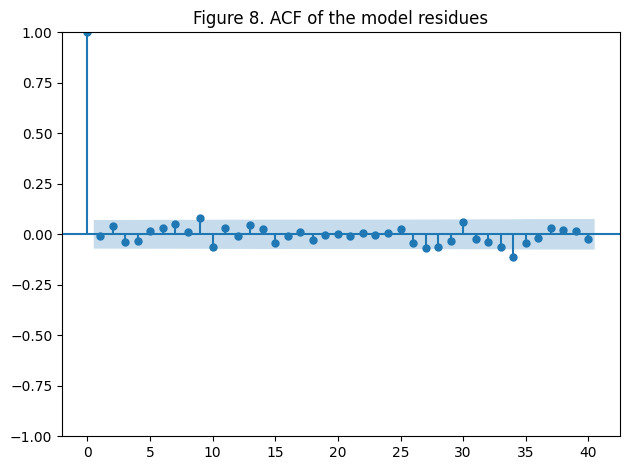

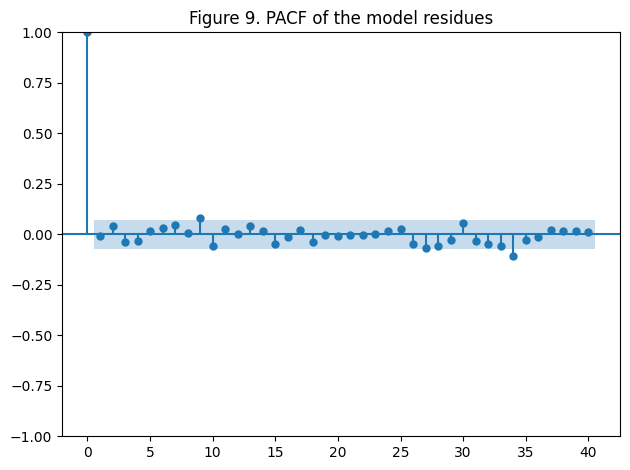

In [36]:

plot_acf(results_2.resid.dropna(), lags=40)
plt.title("Figure 8. ACF of the model residues")
plt.tight_layout()
plt.show()

plot_pacf(results_2.resid.dropna(), lags=40)
plt.title("Figure 9. PACF of the model residues")
plt.tight_layout()
plt.show()

The first lag shows autocorrelation since it does not exceed the confidence intervals.

In [38]:
arima_pred = results_2.predict()
df_plot = pd.DataFrame({
    "Date": arima_pred.index,
    "Real": y_ts,
    "Predicted": arima_pred
})

fig = px.line(df_plot, x="Date", y="Real", title="Figure 10. Real demand vs forecast (ARIMA)")
fig.add_scatter(x=df_plot["Date"], y=df_plot["Predicted"], mode="lines", name="Forecast")
fig.show()

Demand forecasting is similar to actual demand; however, the model does not present a normal distribution of its residuals, therefore, a multivariate or machine learning model can capture external factors.

## **Ramdom Forest**

Due to the outliers in the ARIMA model's residuals, a Random Forest model will be used, as it can model nonlinear relationships and is robust to noise and outliers.

Before making a prediction with random forest, the data frame must be transformed into an encoded matrix, and and add annual, monthly, and daily variables 

In [42]:
df_encoded = pd.get_dummies(df, columns=[
    'Store ID', 'Category', 'Region',
    'Weather Condition', 'Seasonality', 'Product ID'
], drop_first=True)
df_encoded["Year"] = df["Date"].dt.year
df_encoded["Month"] = df["Date"].dt.month
df_encoded["DayOfWeek"] = df["Date"].dt.dayofweek
df_encoded["Day"] = df["Date"].dt.day



## Define dependent and independent variables

In [44]:
X = df_encoded.drop(columns=['Date', 'Demand', 'Units Sold','Units Ordered']) #this variables could cause collinearity
y = df_encoded['Demand']

It is a supervised model, is trained with the 80% of the dataset, and the other 20% is to validate the forcast, the model used 100 decisions trees.

In [46]:
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [47]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Most important variables

This are the most important variables in the model, ordered from highest to lowest

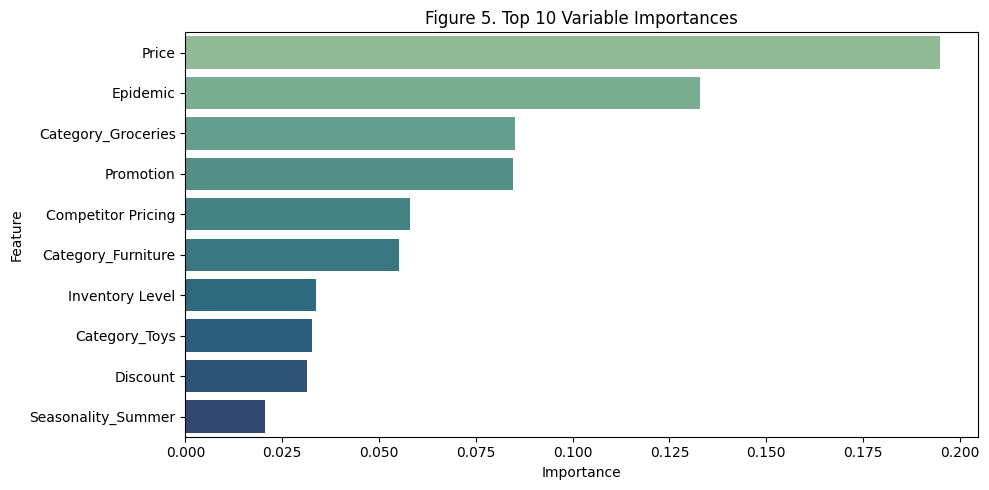

In [50]:
importances = model.feature_importances_
features = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
sns.barplot(x=importances[sorted_idx][:10], y=features[sorted_idx][:10], hue=features[sorted_idx][:10], palette="crest")
plt.title("Figure 5. Top 10 Variable Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## RMSE and MAPE

In [52]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

RMSE: 16.37
MAPE: 16.84%
R²: 0.862


The model fails by 17 units demanded, which corresponds to an average error of 16.48%.

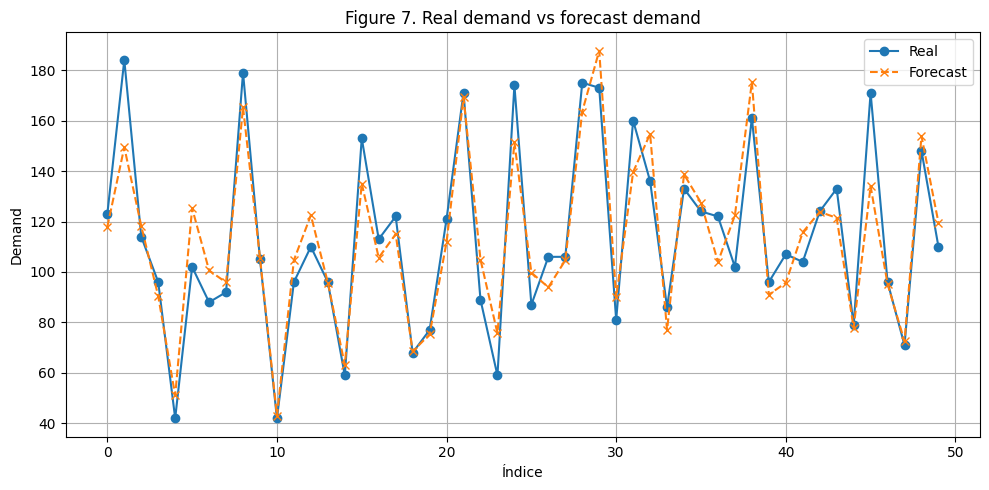

In [54]:
df_resultado = pd.DataFrame({
    'Demanda Real': y_test.values,
    'Demanda Predicha': y_pred
}, index=y_test.index)

plt.figure(figsize=(10, 5))
plt.plot(df_resultado['Demanda Real'].values[:50], label='Real', marker='o')
plt.plot(df_resultado['Demanda Predicha'].values[:50], label='Forecast', linestyle='--', marker='x')
plt.title("Figure 7. Real demand vs forecast demand")
plt.xlabel("Índice")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Proyección.png")
plt.show()

In [55]:
y_pred = model.predict(X_test)

X_test_with_date = X_test.copy()
X_test_with_date["Date"] = df.loc[X_test.index, "Date"]
X_test_with_date["Predicted"] = y_pred

predicted_daily = X_test_with_date.groupby("Date")["Predicted"].sum().reset_index()
real_daily = df.loc[X_test.index].groupby("Date")["Demand"].sum().reset_index()

fig = px.line(real_daily, x="Date", y="Demand", title="Figure 8. Real demand vs Ramdom Forest forecast")
fig.add_scatter(x=predicted_daily["Date"], y=predicted_daily["Predicted"], mode="lines", name="Forecast")
fig.show()

## Conclusions 

The model makes a prediction with an average error of 17%, equivalent to 17 units, but this difference causes the model to overestimate or underestimate demand (Figure 7). 

However, the model's forecast fits real demand well (Figure 8).
The most important variables are price, epidemic (COVID-19), and category groceries. 

Finally, the ARIMA model makes predictions close to actual demand. However, as it is an autoregressive model, it cannot capture variables such as price or the epidemic. This is why the random forest model makes a better forecast. In addition, the random forest model can continue to improve by including new variables that will enhance the model in the future.